In [1]:
import os
import random
from glob import glob
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Label map: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


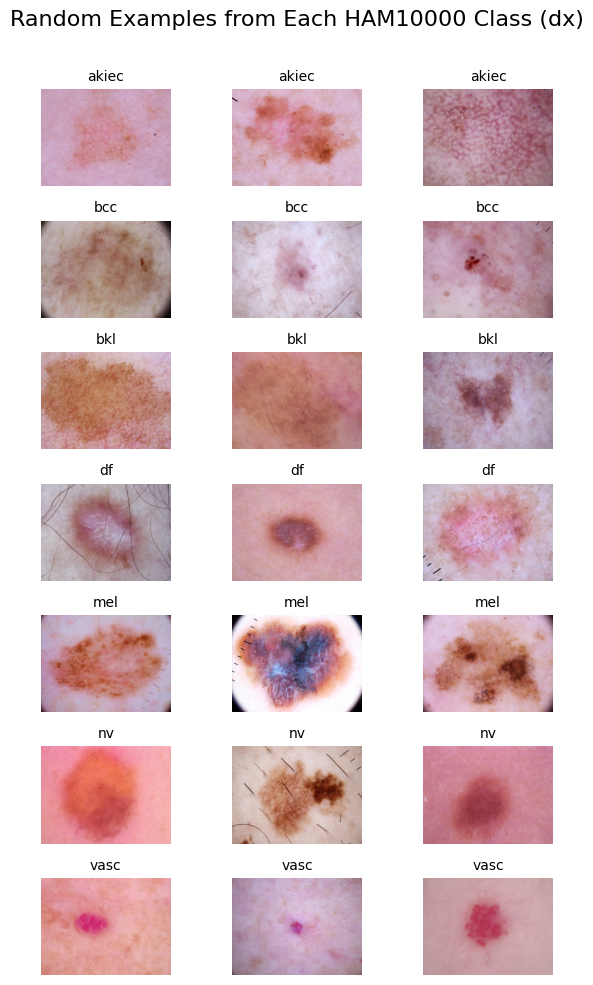

In [ ]:
# 3 random images from each class

import matplotlib.pyplot as plt
import random

random.seed(42)
metadata = pd.read_csv("/content/drive/MyDrive/HAM10000/HAM10000_metadata")
class_names = sorted(metadata["dx"].unique())
labels = metadata["dx"].unique()
label_map = {name: i for i, name in enumerate(labels)}
metadata["label"] = metadata["dx"].map(label_map)
print("Label map:", label_map)

paths_part1 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part1/*.jpg")
paths_part2 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part2/*.jpg")
all_paths = paths_part1 + paths_part2

id_to_path = {os.path.basename(p)[:-4]: p for p in all_paths}

n_classes = len(class_names)
n_per_class = 3

fig, axes = plt.subplots(n_classes, n_per_class, figsize=(6,10))

if n_classes == 1:
    axes = np.expand_dims(axes, axis=0)
if n_per_class == 1:
    axes = np.expand_dims(axes, axis=1)

for row_idx, cls in enumerate(class_names):
    rows_cls = metadata[metadata["dx"] == cls]
    sampled = rows_cls.sample(n=n_per_class, random_state=42)
    for col_idx, (_, row) in enumerate(sampled.iterrows()):
        img_id = row["image_id"]
        img_path = id_to_path[img_id]
        img = Image.open(img_path).convert("RGB")
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=12, rotation=0, labelpad=35, va="center")
        ax.set_title(cls, fontsize=10)

plt.suptitle("Random Examples from Each HAM10000 Class (dx)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


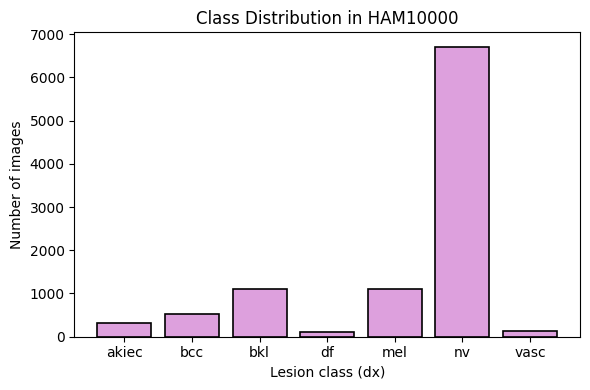

In [ ]:
class_counts = metadata["dx"].value_counts().sort_index()
class_names = class_counts.index.tolist()
counts = class_counts.values

plt.figure(figsize=(6, 4))
bars = plt.bar(
    class_names,
    counts,
    color="plum",
    edgecolor="black",
    linewidth=1.2
)

plt.xlabel("Lesion class (dx)")
plt.ylabel("Number of images")
plt.title("Class Distribution in HAM10000")
plt.xticks()
plt.tight_layout()
plt.show()


In [2]:
import os
from glob import glob
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# selects training device
# if a GPU is not available, run on the CPU (but GPU is much faster for CNNs)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load metadata
metadata = pd.read_csv("/content/drive/MyDrive/HAM10000/HAM10000_metadata")

# converts the label, the diagnosis (dx), into numeric labels (0–6)
labels = metadata["dx"].unique()
label_map = {name: i for i, name in enumerate(labels)}
metadata["label"] = metadata["dx"].map(label_map)
print("Label map:", label_map)

# map image ids to image files
paths_part1 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part1/*.jpg")
paths_part2 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part2/*.jpg")
all_paths = paths_part1 + paths_part2

id_to_path = {os.path.basename(p)[:-4]: p for p in all_paths}
print("Total images found:", len(id_to_path))

# initialize lists to store image paths and their labels
image_paths = []
image_labels = []

for _, row in metadata.iterrows():
    img_id = row["image_id"]
    if img_id in id_to_path:
        image_paths.append(id_to_path[img_id])
        image_labels.append(row["label"])

print("Total usable images:", len(image_paths))

# train/validation split
# once we tune hyperparameters we can include a test set
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.3,
    stratify=image_labels, # makes class proportions consistent for training and validation
    random_state=42
)

print("Train size:", len(train_paths), "Val size:", len(val_paths))

# ----------------------------------
# make (nevi) ~25% of the training set
# ----------------------------------
random.seed(42)

nv_label = label_map["nv"]

# get indices for nv vs non-nv in the training set
nv_indices = []
non_nv_indices = []

for i in range(len(train_labels)):
    if train_labels[i] == nv_label:
        nv_indices.append(i)
    else:
        non_nv_indices.append(i)

# pick how many nv images we want to keep so nv is ~25% of train
# if nv is 25% and non-nv is 75%, then nv = (25/75) * non_nv
target_nv_count = int(len(non_nv_indices) * (0.25 / 0.75))

# randomly keep only that many nv images
nv_indices_downsampled = random.sample(nv_indices, target_nv_count)

# combine nv + non-nv indices and shuffle
balanced_indices = nv_indices_downsampled + non_nv_indices
random.shuffle(balanced_indices)

# build the balanced training lists
train_paths_balanced = []
train_labels_balanced = []

for idx in balanced_indices:
    train_paths_balanced.append(train_paths[idx])
    train_labels_balanced.append(train_labels[idx])
# ----------------------------------

baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

hflip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

vflip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

rotation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

jitter_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

heavy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

moderate_transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.RandomRotation(20),
transforms.ColorJitter(brightness=0.1, contrast=0.1),
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406],
                     [0.229, 0.224, 0.225])
])


### IF ADDING TRANSFORMS, ADD THEM HERE ###

# define image transforms for training images
val_transform = transforms.Compose([
    # make every image the same size
    transforms.Resize((224, 224)),
    # convert PIL image into PyTorch tensor and scale pixel values from 0-255 to 0-1
    transforms.ToTensor(),
    # standardize each channel (match what EfficientNet was trained on)
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# helper function that loads one image at a time and applies transformation
def load_image_tensor(path, transform):
    img = Image.open(path).convert("RGB")
    img = transform(img)
    return img

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Label map: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}
Total images found: 10015
Total usable images: 10015
Train size: 7010 Val size: 3005


In [3]:
from tqdm import tqdm

def run_experiment(
    experiment_name,
    train_transform,
    val_transform,
    epochs,
    batch_size=64,
    save_dir="checkpoints"
):
    print("\n%s" % ("=" * 70))
    print("Training EfficientNet-B5: %s" % experiment_name)
    print("%s" % ("=" * 70))

    os.makedirs(save_dir, exist_ok=True)
    best_model_path = None

    torch.cuda.empty_cache()

    scaler = torch.amp.GradScaler('cuda')

    weights = EfficientNet_B5_Weights.DEFAULT
    model = efficientnet_b5(weights=weights)
    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        len(label_map)
    )
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    best_val_acc = 0.0
    best_val_loss = float("inf")
    early_stopping_patience = 5
    early_stopping_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        print("\nEpoch %d/%d" % (epoch + 1, epochs))

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        indices = np.random.permutation(len(train_paths_balanced))
        num_batches = len(indices) // batch_size

        train_pbar = tqdm(
            range(0, len(indices), batch_size),
            desc="Training",
            ncols=100,
            leave=True
        )

        for start in train_pbar:
            batch_idx = indices[start:start + batch_size]

            batch_imgs = [
                load_image_tensor(train_paths_balanced[i], train_transform)
                for i in batch_idx
            ]
            batch_labs = [train_labels_balanced[i] for i in batch_idx]

            images = torch.stack(batch_imgs).to(device)
            labels = torch.tensor(batch_labs, dtype=torch.long).to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            train_pbar.set_postfix(
                loss="%.4f" % loss.item(),
                acc="%.2f%%" % (100.0 * train_correct / train_total)
            )

            del images, labels, outputs, loss, preds

        train_loss = running_loss / num_batches
        train_acc = 100.0 * train_correct / train_total

        # ===================== VALIDATION =====================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_batches = 0

        val_pbar = tqdm(
            range(0, len(val_paths), batch_size),
            desc="Validation",
            ncols=100,
            leave=True
        )

        with torch.no_grad():
            for start in val_pbar:
                batch_paths = val_paths[start:start + batch_size]
                batch_labs = val_labels[start:start + batch_size]

                batch_imgs = [
                    load_image_tensor(p, val_transform)
                    for p in batch_paths
                ]

                images = torch.stack(batch_imgs).to(device)
                labels = torch.tensor(batch_labs, dtype=torch.long).to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_batches += 1

                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                del images, labels, outputs, preds, batch_imgs, loss

        val_loss /= val_batches
        val_acc = 100.0 * val_correct / val_total

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print("Train Loss: %.4f | Train Acc: %.2f%%" % (train_loss, train_acc))
        print("Val Loss:   %.4f | Val Acc:   %.2f%%" % (val_loss, val_acc))

        # ===================== EARLY STOPPING =====================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            early_stopping_counter = 0

            best_model_path = os.path.join(
                save_dir, "best_%s.pth" % experiment_name
            )
            torch.save(model.state_dict(), best_model_path)

            print("Validation loss improved to %.4f" % best_val_loss)
            print("Model saved to: %s" % best_model_path)
        else:
            early_stopping_counter += 1
            print(
                "Early stopping counter: %d/%d"
                % (early_stopping_counter, early_stopping_patience)
            )
            if early_stopping_counter >= early_stopping_patience:
                print("\nEarly stopping triggered.")
                break

    print("\n%s" % ("=" * 70))
    print("Training complete for %s" % experiment_name)
    print("Best validation accuracy: %.2f%%" % best_val_acc)
    print("Best validation loss: %.4f" % best_val_loss)
    if best_model_path is not None:
        print("Best model saved at: %s" % best_model_path)
    print("%s\n" % ("=" * 70))

    del model, optimizer, scaler
    torch.cuda.empty_cache()

    return best_val_acc, history


In [6]:
def plot_training_curves(history, experiment_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    # -------- Loss --------
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("EfficientNet-B5 Model Loss with %s augmentation and balanced" % experiment_name)
    plt.legend()
    plt.show()

    # -------- Accuracy --------
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("EfficientNet-B5 Model Accuracy with %s augmentation and balanced" % experiment_name)
    plt.legend()
    plt.show()


In [7]:
best_acc, history_baseline = run_experiment(
    experiment_name="baseline",
    train_transform=baseline_transform,
    val_transform=val_transform,
    epochs=20,
    batch_size=16,
    save_dir="checkpoints"
)



Training EfficientNet-B5: baseline
Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:01<00:00, 104MB/s]



Epoch 1/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [09:55<00:00,  3.17s/it]


Train Loss: 1.3897 | Train Acc: 50.24%
Val Loss:   0.7320 | Val Acc:   74.71%
Validation loss improved to 0.7320
Model saved to: checkpoints/best_baseline.pth

Epoch 2/20


...

Train Loss: 0.1400 | Train Acc: 96.31%
Val Loss:   0.6960 | Val Acc:   79.80%
Early stopping counter: 3/5

Epoch 8/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:35<00:00,  5.27it/s]


Train Loss: 0.0789 | Train Acc: 98.03%
Val Loss:   0.6936 | Val Acc:   80.87%
Early stopping counter: 4/5

Epoch 9/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:35<00:00,  5.25it/s]

Train Loss: 0.0750 | Train Acc: 97.73%
Val Loss:   0.5814 | Val Acc:   83.49%
Early stopping counter: 5/5

Early stopping triggered.

Training complete for baseline
Best validation accuracy: 80.70%
Best validation loss: 0.5701
Best model saved at: checkpoints/best_baseline.pth



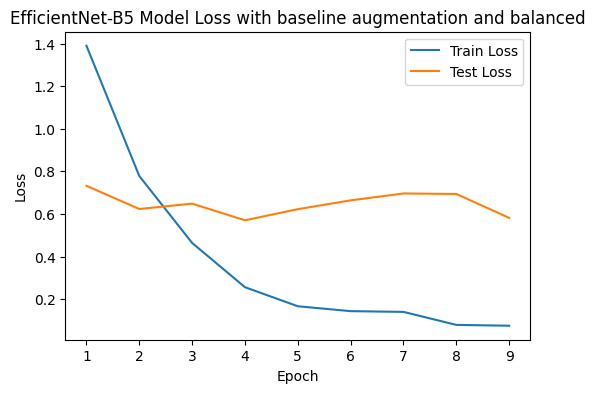

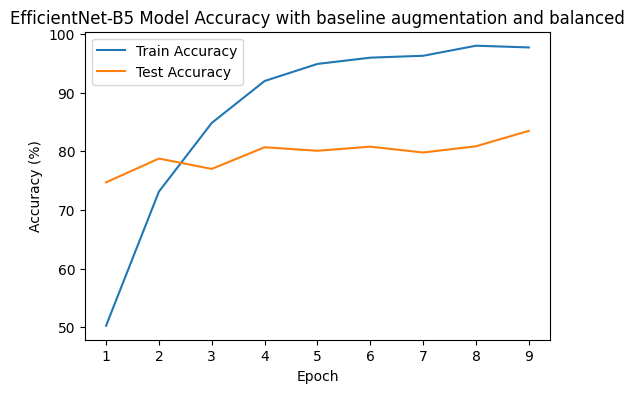

In [10]:
plot_training_curves(history_baseline, "baseline")

In [4]:
best_acc, history_hflip = run_experiment(
    experiment_name="hflip",
    train_transform=hflip_transform,
    val_transform=val_transform,
    epochs=20,
    batch_size=16,
    save_dir="checkpoints"
)


Training EfficientNet-B5: hflip
Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:00<00:00, 137MB/s]



Epoch 1/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [05:26<00:00,  1.74s/it]


Train Loss: 1.3750 | Train Acc: 50.99%
Val Loss:   0.6820 | Val Acc:   77.94%
Validation loss improved to 0.6820
Model saved to: checkpoints/best_hflip.pth

Epoch 2/20


...

Train Loss: 0.0784 | Train Acc: 98.19%
Val Loss:   0.5767 | Val Acc:   82.53%
Early stopping counter: 3/5

Epoch 11/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:36<00:00,  5.17it/s]


Train Loss: 0.0663 | Train Acc: 98.19%
Val Loss:   0.6449 | Val Acc:   81.46%
Early stopping counter: 4/5

Epoch 12/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:36<00:00,  5.14it/s]

Train Loss: 0.0564 | Train Acc: 98.67%
Val Loss:   0.5933 | Val Acc:   82.83%
Early stopping counter: 5/5

Early stopping triggered.

Training complete for hflip
Best validation accuracy: 83.63%
Best validation loss: 0.4933
Best model saved at: checkpoints/best_hflip.pth



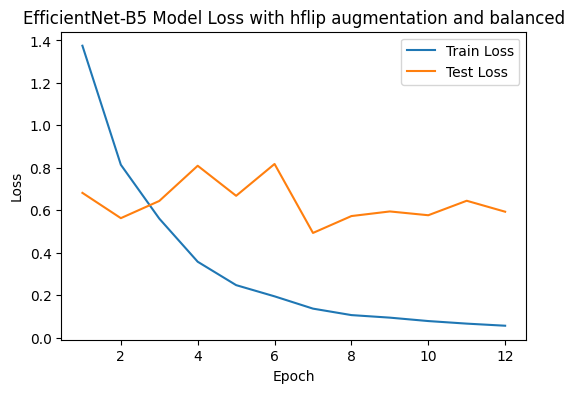

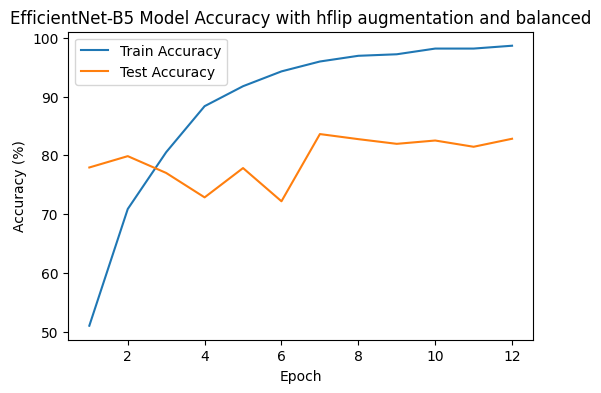

In [7]:
plot_training_curves(history_hflip, "hflip")

In [10]:
best_acc, history_vflip = run_experiment(
    experiment_name="vflip",
    train_transform=vflip_transform,
    val_transform=val_transform,
    epochs=20,
    batch_size=16,
    save_dir="checkpoints"
)


Training EfficientNet-B5: vflip

Epoch 1/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:36<00:00,  5.15it/s]


Train Loss: 1.3892 | Train Acc: 51.38%
Val Loss:   0.7427 | Val Acc:   74.54%
Validation loss improved to 0.7427
Model saved to: checkpoints/best_vflip.pth

Epoch 2/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:36<00:00,  5.12it/s]


Train Loss: 0.8519 | Train Acc: 69.67%
Val Loss:   0.5569 | Val Acc:   81.00%
Validation loss improved to 0.5569
Model saved to: checkpoints/best_vflip.pth

Epoch 3/20


...

Train Loss: 0.1901 | Train Acc: 94.08%
Val Loss:   0.7208 | Val Acc:   77.44%
Early stopping counter: 3/5

Epoch 8/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:36<00:00,  5.20it/s]


Train Loss: 0.1584 | Train Acc: 95.50%
Val Loss:   0.5598 | Val Acc:   82.36%
Early stopping counter: 4/5

Epoch 9/20


Validation: 100%|█████████████████████████████████████████████████| 188/188 [00:36<00:00,  5.19it/s]

Train Loss: 0.1123 | Train Acc: 96.63%
Val Loss:   0.5859 | Val Acc:   82.13%
Early stopping counter: 5/5

Early stopping triggered.

Training complete for vflip
Best validation accuracy: 80.63%
Best validation loss: 0.5427
Best model saved at: checkpoints/best_vflip.pth



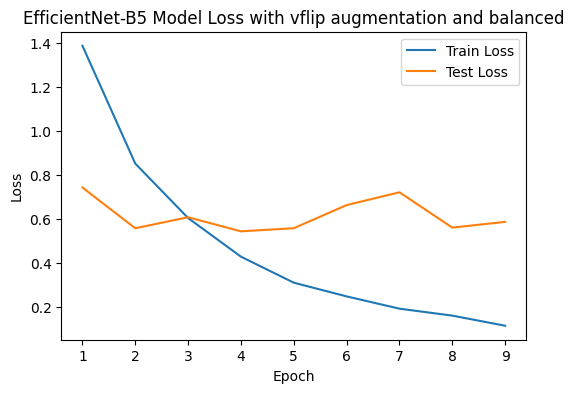

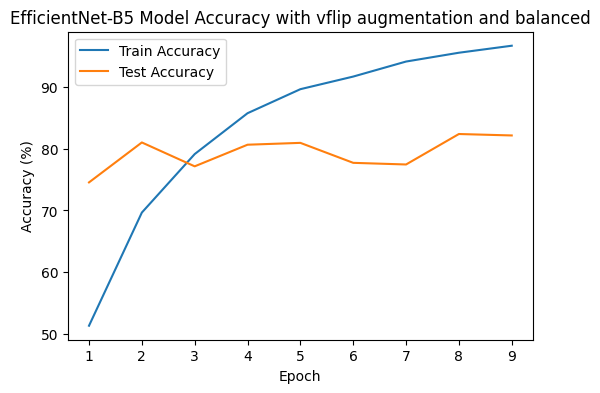

In [11]:
plot_training_curves(history_vflip, "vflip")

In [ ]:
best_acc, history_rotation = run_experiment(
    experiment_name="rotation",
    train_transform=rotation_transform,
    val_transform=val_transform,
    epochs=20,
    batch_size=16,
    save_dir="checkpoints"
)

In [ ]:
best_acc, history_jitter = run_experiment(
    experiment_name="jitter",
    train_transform=jitter_transform,
    val_transform=val_transform,
    epochs=20,
    batch_size=16,
    save_dir="checkpoints"
)

In [ ]:
best_acc, history_heavy = run_experiment(
    experiment_name="heavy",
    train_transform=heavy_transform,
    val_transform=val_transform,
    epochs=20,
    batch_size=16,
    save_dir="checkpoints"
)

In [ ]:
best_acc, history_moderate = run_experiment(
    experiment_name="moderate",
    train_transform=moderate_transform,
    val_transform=val_transform,
    epochs=20,
    batch_size=16,
    save_dir="checkpoints"
)

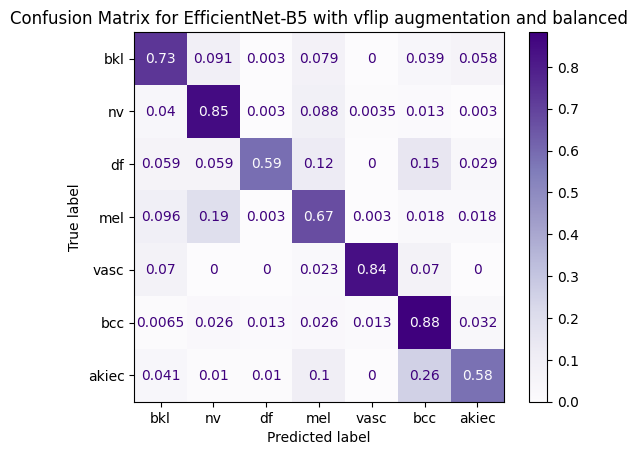

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# rebuild model but with no weights
model_cm = efficientnet_b5(weights=None)
num_classes = len(label_map)
model_cm.classifier[1] = nn.Linear(model_cm.classifier[1].in_features, num_classes)
model_cm = model_cm.to(device)

# load best saved weights
state_dict = torch.load("checkpoints/best_vflip.pth", map_location=device)
model_cm.load_state_dict(state_dict)
model_cm.eval()

# collect predictions from validation set
all_true = []
all_preds = []
batch_size=32
with torch.no_grad():
    for start in range(0, len(val_paths), batch_size):
        batch_paths = val_paths[start:start + batch_size]
        batch_labs = val_labels[start:start + batch_size]

        batch_imgs = []
        for path in batch_paths:
            img_tensor = load_image_tensor(path, val_transform)
            batch_imgs.append(img_tensor)

        images = torch.stack(batch_imgs).to(device)
        labels = torch.tensor(batch_labs, dtype=torch.long).to(device)

        outputs = model_cm(images)
        _, preds = torch.max(outputs, 1)

        all_true.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# make confusion matrix
cm = confusion_matrix(all_true, all_preds, normalize='true')
class_names = list(label_map.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Purples")
plt.title("Confusion Matrix for EfficientNet-B5 with vflip augmentation and balanced")
plt.show()

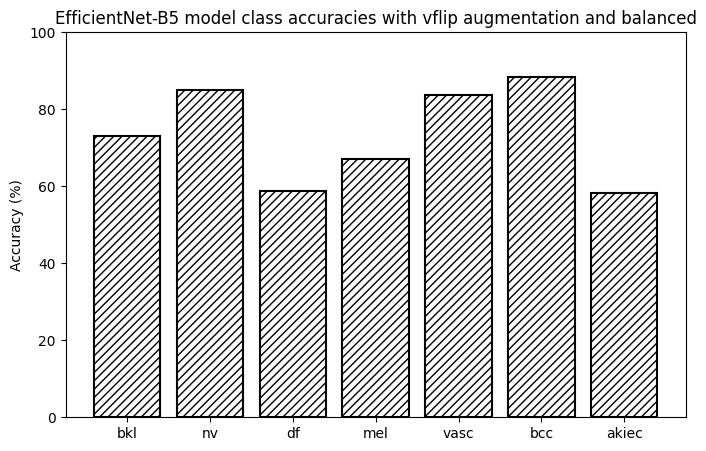

In [13]:
counts = cm.sum(axis=1)
tp = np.diag(cm)
class_accuracies = np.divide(tp, counts)*100

plt.figure(figsize=(8,5))

bars = plt.bar(class_names, class_accuracies,
               hatch="////",
               facecolor="none",
               edgecolor='black',
               linewidth=1.5)

plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.title("EfficientNet-B5 model class accuracies with vflip augmentation and balanced")

plt.show()
